<a href="https://colab.research.google.com/github/masterAristocats/Proc-Sin-Trabalho-Extra/blob/main/examples/steering_vector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Exemplo de utilização

## Objetivo

Implementar a função `steering_vector(positions, azimuth, elevation, wavelength)`, responsável por calcular o vetor diretor de um arranjo de sensores para uma direção de chegada especificada.


In [1]:
!git clone https://github.com/masterAristocats/Proc-Sin-Trabalho-Extra.git

Cloning into 'Proc-Sin-Trabalho-Extra'...
remote: Enumerating objects: 239, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 239 (delta 29), reused 2 (delta 2), pack-reused 162 (from 1)
Receiving objects: 100% (239/239), 13.91 MiB | 22.06 MiB/s, done.
Resolving deltas: 100% (98/98), done.


In [2]:
%cd Proc-Sin-Trabalho-Extra

!ls src

/content/Proc-Sin-Trabalho-Extra
beamformer.py	generate_uca.py   generate_ula.py  steering_vector.py
beampattern.py	generate_ucya.py  generate_upa.py


In [3]:
import numpy as np

from src.generate_ula import generate_ula
from src.steering_vector import steering_vector

In [4]:
M = 9
wavelength = 1.0
d = wavelength / 2

positions = generate_ula(M, d)

## Cálculo do Steering Vector

Neste exemplo considera-se uma onda incidindo na direção de azimute igual a **0°** e elevação igual a **0°**.

In [5]:
a = steering_vector(
    positions,
    azimuth=0,
    elevation=0,
    wavelength=wavelength
)

print(a)

[ 1.+0.00000000e+00j -1.-1.22464680e-16j  1.+2.44929360e-16j
 -1.-3.67394040e-16j  1.+4.89858720e-16j -1.-6.12323400e-16j
  1.+7.34788079e-16j -1.-8.57252759e-16j  1.+9.79717439e-16j]


## Módulo do Steering Vector

Como cada elemento do vetor diretor possui módulo unitário, espera-se que todos os sensores apresentem ganho igual a 1. As diferenças entre os elementos aparecem apenas na fase.

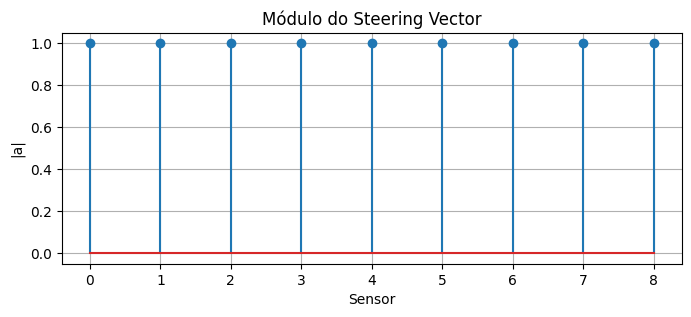

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))

plt.stem(np.abs(a))

plt.title("Módulo do Steering Vector")
plt.xlabel("Sensor")
plt.ylabel("|a|")

plt.grid(True)

plt.show()

## Fase do Steering Vector

A fase varia de sensor para sensor em função da diferença de percurso da onda incidente. Essa variação é responsável pelo alinhamento espacial utilizado posteriormente pelo beamformer.

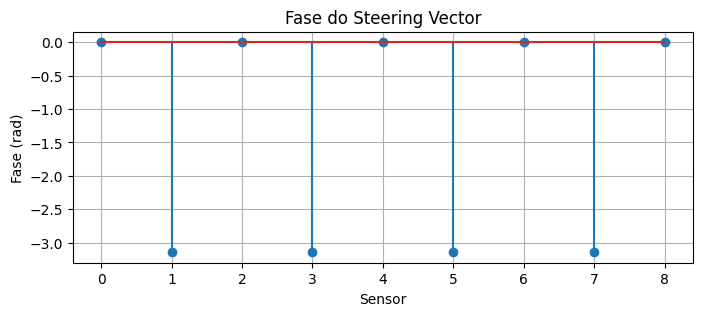

In [7]:
plt.figure(figsize=(8,3))

plt.stem(np.angle(a))

plt.title("Fase do Steering Vector")

plt.xlabel("Sensor")
plt.ylabel("Fase (rad)")

plt.grid(True)

plt.show()

## Influência da Direção de Chegada

A seguir é apresentado o comportamento da fase do vetor diretor para diferentes direções de chegada da onda incidente.

In [8]:
angles = [0, 30, 60]

Text(0.5, 1.0, 'Steering Vector para diferentes direções')

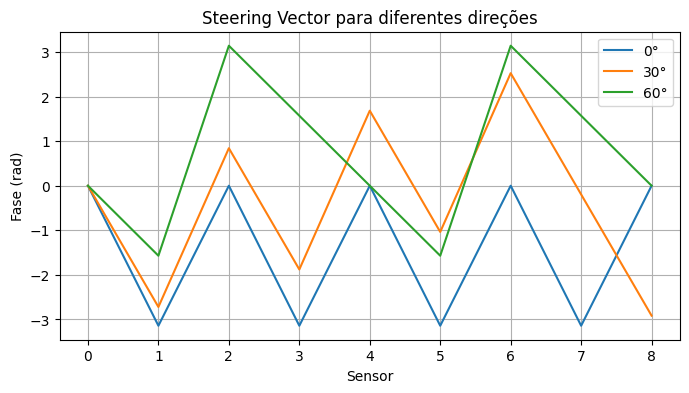

In [9]:
plt.figure(figsize=(8,4))

for ang in angles:

    a = steering_vector(
        positions,
        np.deg2rad(ang),
        0,
        wavelength
    )

    plt.plot(
        np.angle(a),
        label=f"{ang}°"
    )

plt.legend()

plt.grid(True)

plt.xlabel("Sensor")
plt.ylabel("Fase (rad)")

plt.title("Steering Vector para diferentes direções")

## Representação do Steering Vector no Plano Complexo

Cada elemento do vetor diretor é um número complexo da forma

\[
a_m = e^{-jk\mathbf{r}_m^T\mathbf{u}}.
\]

Como o módulo de uma exponencial complexa é sempre igual a 1, todos os elementos do vetor diretor pertencem à circunferência unitária do plano complexo.

A figura abaixo apresenta a distribuição desses elementos no plano complexo para a direção de incidência considerada. Observa-se que as diferenças entre os sensores são representadas exclusivamente por variações de fase.

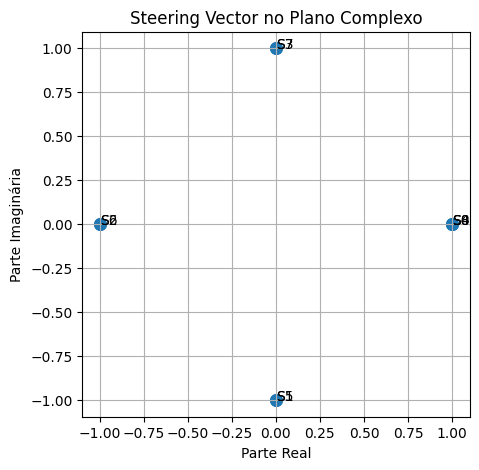

In [10]:
plt.figure(figsize=(5,5))

plt.scatter(
    np.real(a),
    np.imag(a),
    s=70
)

for i in range(len(a)):
    plt.text(
        np.real(a[i]),
        np.imag(a[i]),
        f"S{i}"
    )

plt.xlabel("Parte Real")
plt.ylabel("Parte Imaginária")

plt.title("Steering Vector no Plano Complexo")

plt.grid(True)
plt.axis("equal")

plt.show()

# Vetor Diretor (Steering Vector)

## Modelagem Matemática

Considere um arranjo composto por **M sensores** posicionados nas coordenadas

\[
\mathbf r_m=
\begin{bmatrix}
x_m\\
y_m\\
z_m
\end{bmatrix},
\qquad
m=1,\ldots,M.
\]

Uma onda plana incidente proveniente da direção definida pelos ângulos de azimute \(\phi\) e elevação \(\theta\) possui vetor unitário de propagação

\[
\mathbf u=
\begin{bmatrix}
\cos\theta\cos\phi\\
\cos\theta\sin\phi\\
\sin\theta
\end{bmatrix}.
\]

O número de onda é definido por

\[
k=\frac{2\pi}{\lambda},
\]

onde \(\lambda\) representa o comprimento de onda.

O vetor diretor é então calculado por

\[
\mathbf a(\theta,\phi)=
\begin{bmatrix}
e^{-jk\mathbf r_1^T\mathbf u}\\
e^{-jk\mathbf r_2^T\mathbf u}\\
\vdots\\
e^{-jk\mathbf r_M^T\mathbf u}
\end{bmatrix}.
\]

Cada elemento representa o atraso de fase observado por um sensor para uma determinada direção de chegada da onda.